      time_unix                datetime_utc  \
0  8.204544e+08         1996-01-01T00:00:00   
1  8.226679e+08  1996-01-26T14:51:42.204409   
2  8.248814e+08  1996-02-21T05:43:24.408818   
3  8.270949e+08  1996-03-17T20:35:06.613226   
4  8.293084e+08  1996-04-12T11:26:48.817635   

   J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]  
0                             1.149700  
1                             1.156212  
2                             1.163468  
3                             1.175437  
4                             1.191470  


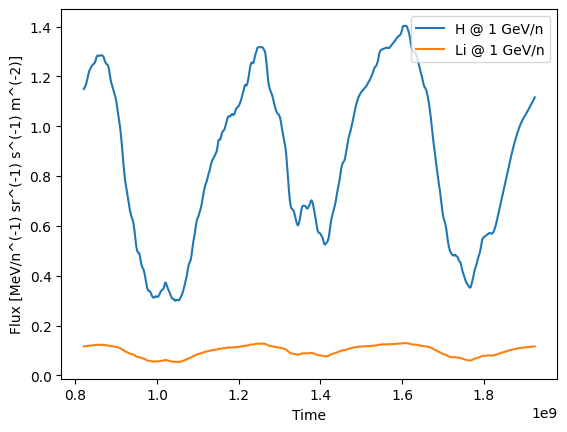

In [ ]:
import pglis
import datetime
import pandas as pd
import matplotlib.pyplot as plt

# initialise
model = pglis.Model()


# helper: date unix timestamp
def dt(year, month, day):
    return datetime.datetime(year, month, day, tzinfo=datetime.timezone.utc).timestamp()


# ── flux vs time
df = pglis.get_flux_vs_time(
    model,
    Z=1,  # Hydrogen
    Ekn=1000.0,  # MeV/n
    t_start=dt(1996, 1, 1),
    t_end=dt(2031, 1, 1),
    n_points=500,
)
print(df.head())

df2 = pglis.get_flux_vs_time(
    model,
    Z=2,  # Hydrogen
    Ekn=1000.0,  # MeV/n
    t_start=dt(1996, 1, 1),
    t_end=dt(2031, 1, 1),
    n_points=500,
)


fig, ax = plt.subplots()

ax.plot(df["time_unix"], df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 1 GeV/n")
ax.plot(
    df2["time_unix"], df2["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="Li @ 1 GeV/n"
)
ax.set_xlabel("Time")
ax.set_ylabel("Flux [MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]")


ax.legend()
plt.show()

In [2]:
import pglis, datetime

model = pglis.Model()

t = datetime.datetime(2001, 6, 1).timestamp()

df = pglis.get_flux_vs_energy(model, Z=1, time=t)

df.head()

,Ekn[MeV/n],J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]
0,10.000000,0.017637
1,10.473709,0.018321
2,10.969858,0.019032
3,11.489510,0.019770
4,12.033778,0.020537


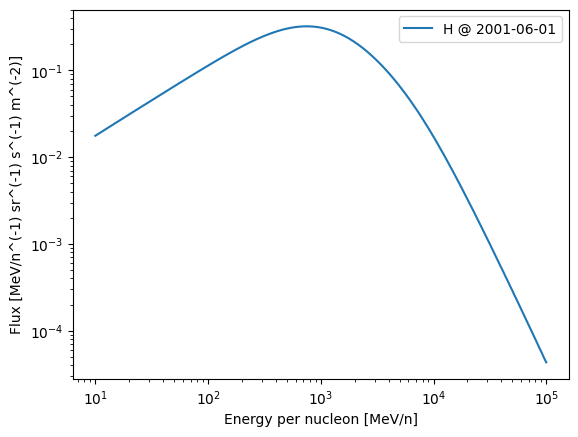

In [3]:
# plot
fig, ax = plt.subplots()
ax.plot(
    df["Ekn[MeV/n]"], df["J[MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]"], label="H @ 2001-06-01"
)
ax.set_xlabel("Energy per nucleon [MeV/n]")
# log scale
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Flux [MeV/n^(-1) sr^(-1) s^(-1) m^(-2)]")
ax.legend()
plt.show()